In [12]:
stores.head(5)

,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South
3,4,B,88289,North
4,5,A,218696,North


In [13]:
features.head()

,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter
3,1,2022-01-22,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,0,NaN,Winter
4,1,2022-01-29,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,0,NaN,Winter


In [14]:
sales = pd.read_csv("../archive/sales.csv")
features = pd.read_csv("../archive/features.csv")
stores = pd.read_csv("../archive/stores.csv")

print("Sales Shape:", sales.shape)
print("Features Shape:", features.shape)
print("Stores Shape:", stores.shape)

Sales Shape: (156000, 5)
Features Shape: (7800, 14)
Stores Shape: (50, 4)


In [15]:
sales.head()

,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [17]:
import pandas as pd

features = pd.read_csv("../archive/features.csv")
sales = pd.read_csv("../archive/sales.csv")
stores = pd.read_csv("../archive/stores.csv")

print("FEATURES COLUMNS:")
print(features.columns.tolist())

print("\nSALES COLUMNS:")
print(sales.columns.tolist())

print("\nSTORES COLUMNS:")
print(stores.columns.tolist())

FEATURES COLUMNS:
['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']

SALES COLUMNS:
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']

STORES COLUMNS:
['store_id', 'store_type', 'store_size', 'region']


In [18]:
sales.info()
features.info()
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store_id      156000 non-null  int64  
 1   department    156000 non-null  int64  
 2   date          156000 non-null  str    
 3   weekly_sales  156000 non-null  float64
 4   is_holiday    156000 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 7.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store_id      7800 non-null   int64  
 1   date          7800 non-null   str    
 2   temperature   7800 non-null   float64
 3   fuel_price    7800 non-null   float64
 4   markdown_1    7800 non-null   float64
 5   markdown_2    7800 non-null   float64
 6   markdown_3    7800 non-null   float64
 7   markdown_4    7800 non-null   float64
 8   mark

In [19]:
print(sales.isnull().sum())
print(features.isnull().sum())
print(stores.isnull().sum())

store_id        0
department      0
date            0
weekly_sales    0
is_holiday      0
dtype: int64
store_id           0
date               0
temperature        0
fuel_price         0
markdown_1         0
markdown_2         0
markdown_3         0
markdown_4         0
markdown_5         0
cpi                0
unemployment       0
is_holiday         0
holiday_name    6900
season             0
dtype: int64
store_id      0
store_type    0
store_size    0
region        0
dtype: int64


In [20]:
print("Sales duplicates:", sales.duplicated().sum())
print("Features duplicates:", features.duplicated().sum())
print("Stores duplicates:", stores.duplicated().sum())

Sales duplicates: 0
Features duplicates: 0
Stores duplicates: 0


In [21]:
sales.describe()

,store_id,department,weekly_sales,is_holiday
count,156000.000000,156000.0000,156000.000000,156000.000000
mean,25.500000,10.5000,56503.488802,0.115385
std,14.430916,5.7663,46717.490663,0.319487
min,1.000000,1.0000,819.660000,0.000000
25%,13.000000,5.7500,21255.962500,0.000000
50%,25.500000,10.5000,43394.870000,0.000000
75%,38.000000,15.2500,79604.107500,0.000000
max,50.000000,20.0000,505958.730000,1.000000


In [26]:
print(sales.columns.tolist())
print(features.columns.tolist())

['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']
['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']


In [27]:
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
features["date"] = pd.to_datetime(features["date"], errors="coerce")

In [29]:
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
features["date"] = pd.to_datetime(features["date"], errors="coerce")

In [30]:
print(sales["date"].head())
print(features["date"].head())

0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
Name: date, dtype: datetime64[us]
0   2022-01-01
1   2022-01-08
2   2022-01-15
3   2022-01-22
4   2022-01-29
Name: date, dtype: datetime64[us]


In [31]:
sales.columns = sales.columns.str.strip().str.lower()
features.columns = features.columns.str.strip().str.lower()
stores.columns = stores.columns.str.strip().str.lower()

In [33]:
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
features["date"] = pd.to_datetime(features["date"], errors="coerce")

In [34]:
print("SALES:", sales.columns.tolist())
print("FEATURES:", features.columns.tolist())
print("STORES:", stores.columns.tolist())

SALES: ['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']
FEATURES: ['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']
STORES: ['store_id', 'store_type', 'store_size', 'region']


In [35]:
df = pd.merge(
    sales,
    features,
    on=["store_id", "date"],
    how="left"
)

In [37]:
df = pd.merge(
    df,
    stores,
    on="store_id",
    how="left"
)

In [38]:
df.head()

,store_id,department,date,weekly_sales,is_holiday_x,temperature,fuel_price,markdown_1,markdown_2,markdown_3,...,unemployment,is_holiday_y,holiday_name,season,store_type_x,store_size_x,region_x,store_type_y,store_size_y,region_y
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,1,New Year,Winter,A,213810,North,A,213810,North
1,1,2,2022-01-01,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,1,New Year,Winter,A,213810,North,A,213810,North
2,1,3,2022-01-01,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,1,New Year,Winter,A,213810,North,A,213810,North
3,1,4,2022-01-01,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,1,New Year,Winter,A,213810,North,A,213810,North
4,1,5,2022-01-01,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,...,3.32,1,New Year,Winter,A,213810,North,A,213810,North


In [39]:
df.shape

(156000, 23)

In [40]:
df.columns.tolist()

['store_id',
 'department',
 'date',
 'weekly_sales',
 'is_holiday_x',
 'temperature',
 'fuel_price',
 'markdown_1',
 'markdown_2',
 'markdown_3',
 'markdown_4',
 'markdown_5',
 'cpi',
 'unemployment',
 'is_holiday_y',
 'holiday_name',
 'season',
 'store_type_x',
 'store_size_x',
 'region_x',
 'store_type_y',
 'store_size_y',
 'region_y']

In [41]:
df.isnull().sum().sort_values(ascending=False)

holiday_name    138000
department           0
store_id             0
weekly_sales         0
is_holiday_x         0
temperature          0
date                 0
fuel_price           0
markdown_1           0
markdown_3           0
markdown_2           0
markdown_5           0
cpi                  0
unemployment         0
markdown_4           0
is_holiday_y         0
season               0
store_type_x         0
store_size_x         0
region_x             0
store_type_y         0
store_size_y         0
region_y             0
dtype: int64

In [42]:
markdown_cols = [
    "markdown_1",
    "markdown_2",
    "markdown_3",
    "markdown_4",
    "markdown_5"
]

for col in markdown_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [43]:
if "cpi" in df.columns:
    df["cpi"] = df["cpi"].fillna(df["cpi"].median())

if "unemployment" in df.columns:
    df["unemployment"] = df["unemployment"].fillna(
        df["unemployment"].median()
    )

In [44]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter

In [45]:
df.isnull().sum().sort_values(ascending=False)

holiday_name    138000
department           0
store_id             0
weekly_sales         0
is_holiday_x         0
temperature          0
fuel_price           0
markdown_1           0
markdown_2           0
markdown_3           0
date                 0
markdown_4           0
markdown_5           0
unemployment         0
cpi                  0
is_holiday_y         0
season               0
store_type_x         0
store_size_x         0
region_x             0
store_type_y         0
store_size_y         0
region_y             0
year                 0
month                0
week                 0
quarter              0
dtype: int64

In [46]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

KeyError: 'Date'

In [47]:
sales.columns = sales.columns.str.strip().str.lower()
features.columns = features.columns.str.strip().str.lower()
stores.columns = stores.columns.str.strip().str.lower()

In [48]:
print("SALES COLUMNS:")
print(sales.columns.tolist())

print("\nFEATURES COLUMNS:")
print(features.columns.tolist())

print("\nSTORES COLUMNS:")
print(stores.columns.tolist())

SALES COLUMNS:
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']

FEATURES COLUMNS:
['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']

STORES COLUMNS:
['store_id', 'store_type', 'store_size', 'region']


In [49]:
df = pd.merge(
    sales,
    features,
    on=["store_id", "date"],
    how="left",
    suffixes=("_sales", "_features")
)

In [50]:
df = pd.merge(
    df,
    stores,
    on="store_id",
    how="left"
)

In [51]:
df.head()

,store_id,department,date,weekly_sales,is_holiday_sales,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday_features,holiday_name,season,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
1,1,2,2022-01-01,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
2,1,3,2022-01-01,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
3,1,4,2022-01-01,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
4,1,5,2022-01-01,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North


In [85]:
print("Merged Shape:", df.shape)
print(df.columns.tolist())

Merged Shape: (156000, 26)
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday_sales', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday_features', 'holiday_name', 'season', 'store_type', 'store_size', 'region', 'Year', 'Month', 'Week', 'Day', 'Quarter', 'Season']


In [53]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [54]:
df = df.drop_duplicates()

In [55]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

holiday_name           138000
store_id                    0
date                        0
department                  0
weekly_sales                0
is_holiday_sales            0
fuel_price                  0
temperature                 0
markdown_2                  0
markdown_3                  0
markdown_4                  0
markdown_1                  0
markdown_5                  0
cpi                         0
unemployment                0
is_holiday_features         0
season                      0
store_type                  0
store_size                  0
region                      0
dtype: int64


In [56]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

holiday_name           88.461538
store_id                0.000000
date                    0.000000
department              0.000000
weekly_sales            0.000000
is_holiday_sales        0.000000
fuel_price              0.000000
temperature             0.000000
markdown_2              0.000000
markdown_3              0.000000
markdown_4              0.000000
markdown_1              0.000000
markdown_5              0.000000
cpi                     0.000000
unemployment            0.000000
is_holiday_features     0.000000
season                  0.000000
store_type              0.000000
store_size              0.000000
region                  0.000000
dtype: float64


In [57]:
markdown_cols = [
    "markdown_1",
    "markdown_2",
    "markdown_3",
    "markdown_4",
    "markdown_5"
]

for col in markdown_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [59]:
if "cpi" in df.columns:
    df["cpi"] = df["cpi"].fillna(df["cpi"].median())

In [60]:
if "unemployment" in df.columns:
    df["unemployment"] = df["unemployment"].fillna(
        df["unemployment"].median()
    )

In [61]:
print(df.isnull().sum().sort_values(ascending=False))

holiday_name           138000
store_id                    0
date                        0
department                  0
weekly_sales                0
is_holiday_sales            0
fuel_price                  0
temperature                 0
markdown_2                  0
markdown_3                  0
markdown_4                  0
markdown_1                  0
markdown_5                  0
cpi                         0
unemployment                0
is_holiday_features         0
season                      0
store_type                  0
store_size                  0
region                      0
dtype: int64


In [63]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Week"] = df["date"].dt.isocalendar().week.astype(int)
df["Day"] = df["date"].dt.day
df["Quarter"] = df["date"].dt.quarter

In [64]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [65]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

In [66]:
df.to_csv(
    "../data/processed/clean_retail_sales.csv",
    index=False
)

# Exploratory Data Analysis (EDA)

TOTAL SALES


In [68]:
total_sales = df["weekly_sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 8814544253.11


average weekly sales


In [70]:
average_sales = df["weekly_sales"].mean()

print("Average Weekly Sales:", average_sales)

Average Weekly Sales: 56503.48880198719


In [74]:
store_sales = (
    df.groupby("store_id")["weekly_sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

store_id
32    3.032230e+08
41    3.018119e+08
5     3.000639e+08
1     2.999050e+08
11    2.923540e+08
37    2.913743e+08
6     2.901179e+08
47    2.857667e+08
38    2.807494e+08
23    2.796390e+08
Name: weekly_sales, dtype: float64

This visualization identifies the stores contributing the highest revenue.

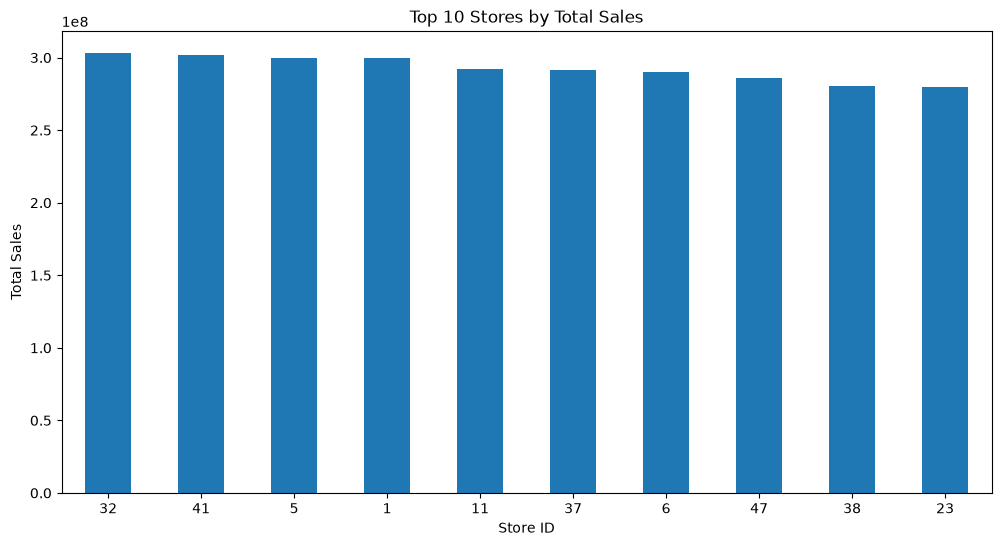

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

store_sales.head(10).plot(kind="bar")

plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

In [76]:
print(df.columns.tolist())

['store_id', 'department', 'date', 'weekly_sales', 'is_holiday_sales', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday_features', 'holiday_name', 'season', 'store_type', 'store_size', 'region', 'Year', 'Month', 'Week', 'Day', 'Quarter', 'Season']


monthly sales trend

In [78]:
monthly_sales = (
    df.groupby(["Year", "Month"])["weekly_sales"]
    .sum()
    .reset_index()
)

monthly_sales["YearMonth"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

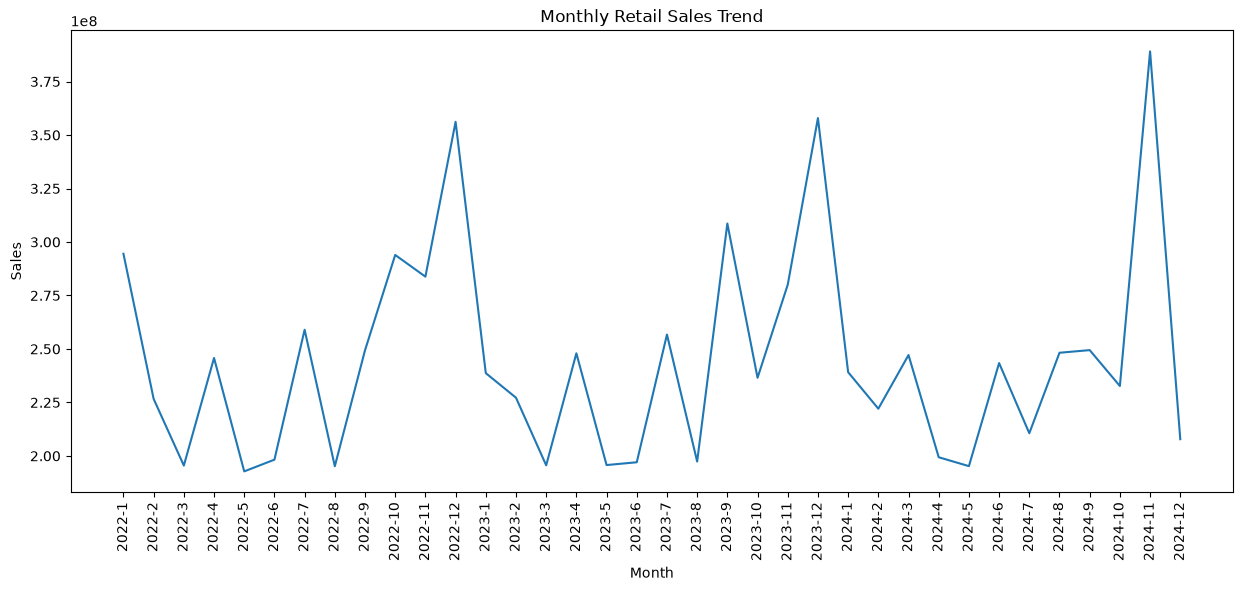

In [80]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["weekly_sales"]
)

plt.title("Monthly Retail Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

holiday impact


In [86]:
holiday_sales = (
    df.groupby("is_holiday_sales")["weekly_sales"]
    .mean()
)

holiday_sales

is_holiday_sales
0    52852.575328
1    84493.825439
Name: weekly_sales, dtype: float64

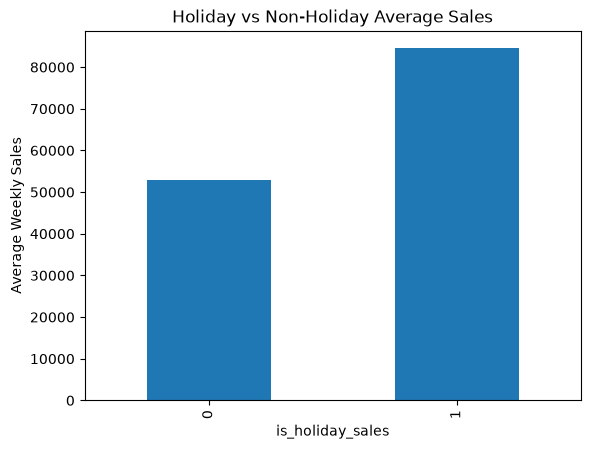

In [87]:
holiday_sales.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Average Sales")
plt.ylabel("Average Weekly Sales")

plt.show()

store type analysis

In [94]:
type_sales = (
    df.groupby("store_type")["weekly_sales"]
    .mean()
    .sort_values(ascending=False)
)

type_sales

store_type
A    80066.725003
B    38353.554613
C    16222.839528
Name: weekly_sales, dtype: float64

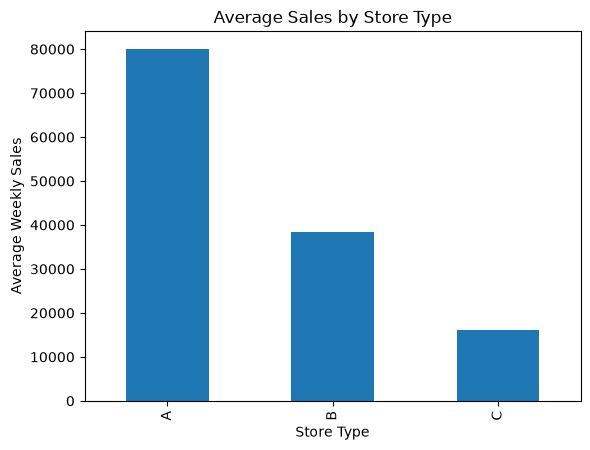

In [90]:
type_sales.plot(kind="bar")

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")

plt.show()

Department Analysis

In [95]:
department_sales = (
    df.groupby("department")["weekly_sales"]
    .sum()
    .sort_values(ascending=False)
)

department_sales.head(10)

department
20    5.923036e+08
19    5.725349e+08
18    5.601886e+08
17    5.398004e+08
16    5.296860e+08
15    5.089252e+08
14    4.917602e+08
13    4.749228e+08
12    4.671906e+08
11    4.541135e+08
Name: weekly_sales, dtype: float64

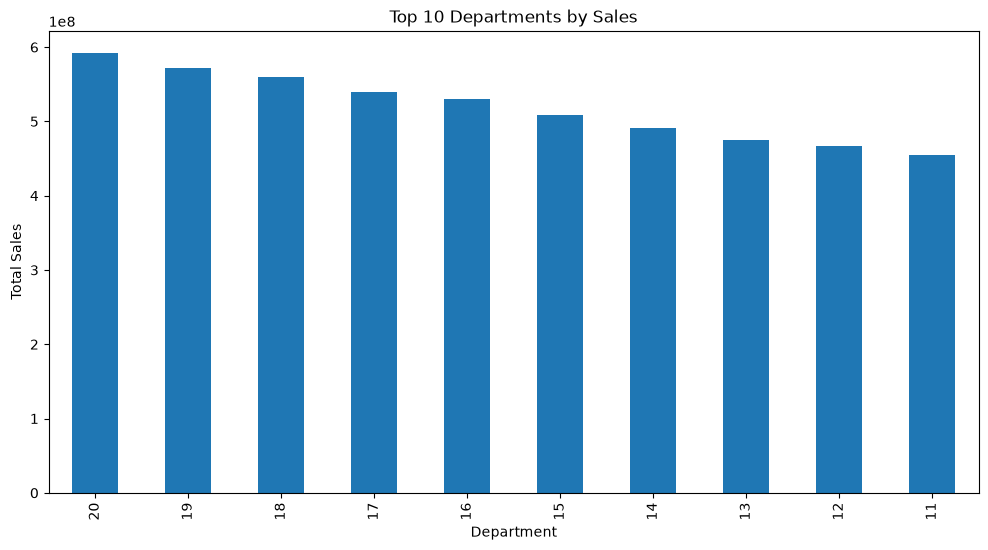

In [96]:
plt.figure(figsize=(12,6))

department_sales.head(10).plot(kind="bar")

plt.title("Top 10 Departments by Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.show()

correlation analysis

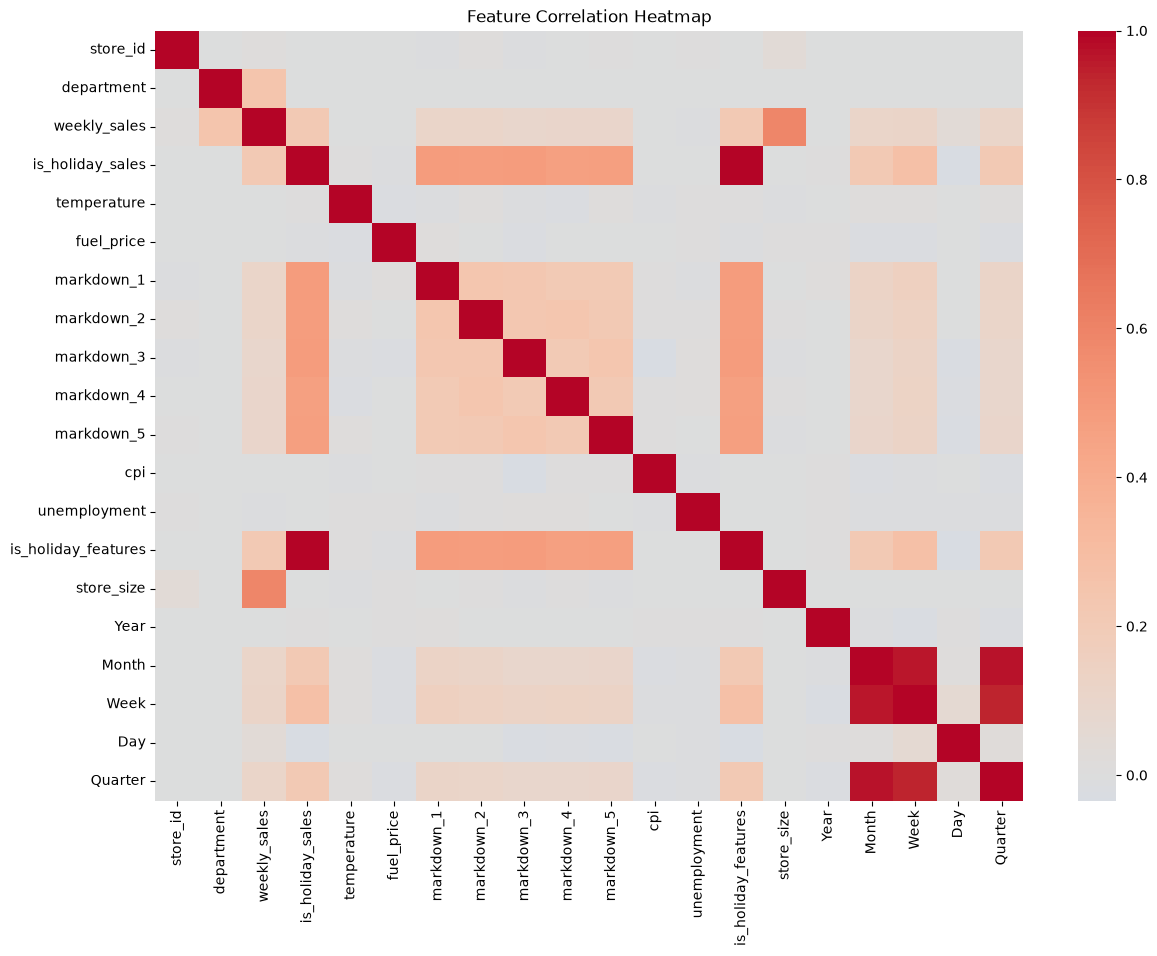

In [97]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

Time Series Visualization


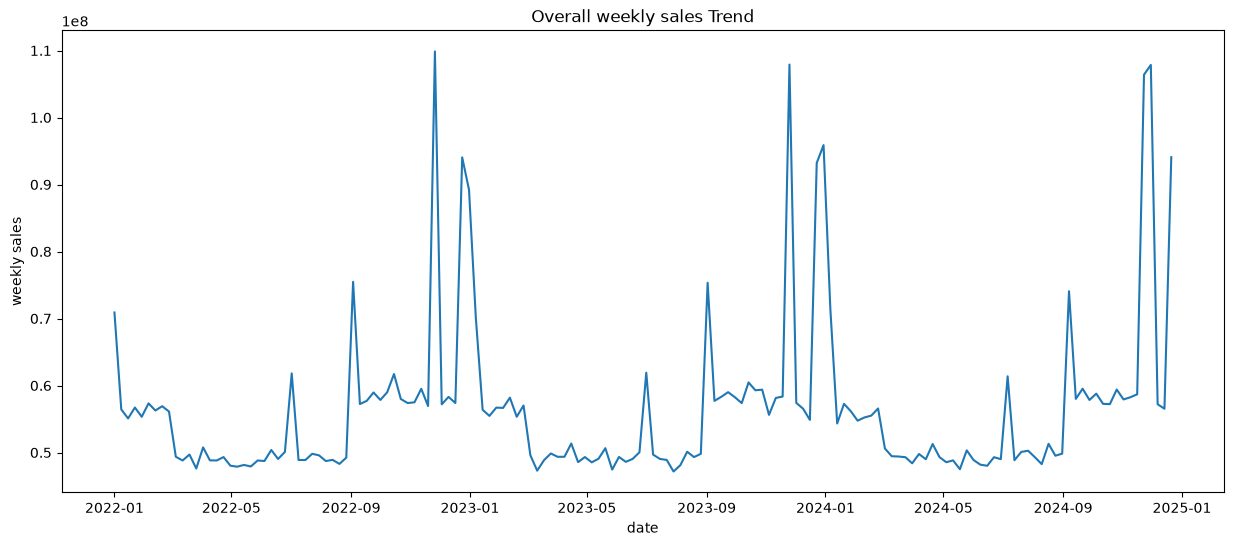

In [100]:
weekly_trend = (
    df.groupby("date")["weekly_sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    weekly_trend["date"],
    weekly_trend["weekly_sales"]
)

plt.title("Overall weekly sales Trend")
plt.xlabel("date")
plt.ylabel("weekly sales")

plt.show()

******* MACHINE LEARNING MODEL ******

In [109]:
model_features = [
    "store_id",
    "is_holiday_sales",
    "temperature",
    "fuel_price",
    "cpi",
    "unemployment",
    "Year",
    "Month",
    "Week"
]

In [110]:
if "dept_id" in df.columns:
    model_features.append("dept_id")

In [111]:
for col in ["lag_1_sales", "lag_4_sales", "rolling_4_week_avg"]:
    if col in df.columns:
        model_features.append(col)

In [112]:
print(model_features)

['store_id', 'is_holiday_sales', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'Year', 'Month', 'Week']


In [113]:
model_df = df.copy()

In [114]:
lag_cols = [
    col for col in [
        "lag_1_sales",
        "lag_4_sales",
        "rolling_4_week_avg"
    ]
    if col in model_df.columns
]

if lag_cols:
    model_df = model_df.dropna(subset=lag_cols)

In [115]:
X = model_df[model_features].copy()
y = model_df["weekly_sales"].copy()

In [116]:
if "is_holiday" in X.columns:
    X["is_holiday"] = X["is_holiday"].astype(int)

In [117]:
X = X.fillna(
    X.median(numeric_only=True)
)

In [118]:
model_df = model_df.sort_values("date").reset_index(drop=True)

In [119]:
X = model_df[model_features].copy()
y = model_df["weekly_sales"].copy()

if "is_holiday" in X.columns:
    X["is_holiday"] = X["is_holiday"].astype(int)

X = X.fillna(
    X.median(numeric_only=True)
)

TRAIN and TEST data 

In [120]:
split_index = int(len(X) * 0.80)

In [121]:
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [122]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (124800, 9)
Testing Data: (31200, 9)


I used a chronological 80-20 split because forecasting should respect time order. in cell 122


Random forest model

In [123]:
from sklearn.ensemble import RandomForestRegressor

In [124]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [125]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [126]:
rf_predictions = rf_model.predict(X_test)

In [127]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [128]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

In [129]:
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 27477.298321816714
Random Forest RMSE: 38723.887437878264
Random Forest R2: 0.40991480316204254


## Actual vs Predicted Sales

In [131]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

results.head()

,Actual,Predicted
0,39417.23,74644.522852
1,16018.74,74644.522852
2,22512.94,61989.996560
3,22479.93,61989.996560
4,182351.42,61989.996560


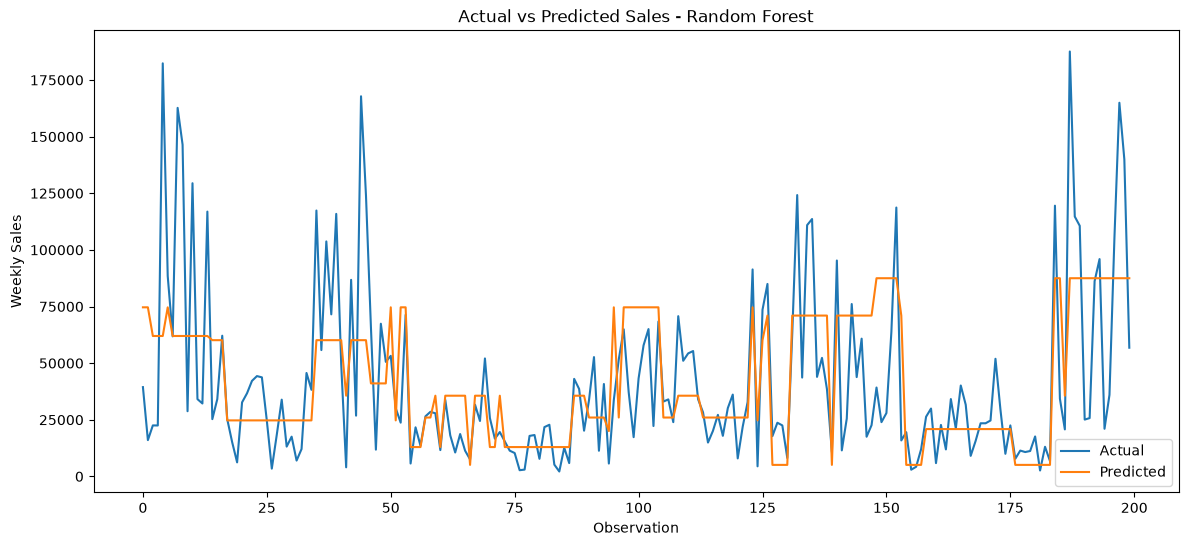

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    results["Actual"].iloc[:200].values,
    label="Actual"
)

plt.plot(
    results["Predicted"].iloc[:200].values,
    label="Predicted"
)

plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Observation")
plt.ylabel("Weekly Sales")
plt.legend()

plt.show()

This graph compares actual sales with the sales predicted by the Random Forest model. in cell 132

## Feature Importance

In [133]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

In [134]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,store_id,0.737992
1,is_holiday_sales,0.084416
5,unemployment,0.031042
7,Month,0.030879
4,cpi,0.028697
2,temperature,0.027851
8,Week,0.027522
3,fuel_price,0.026689
6,Year,0.004912


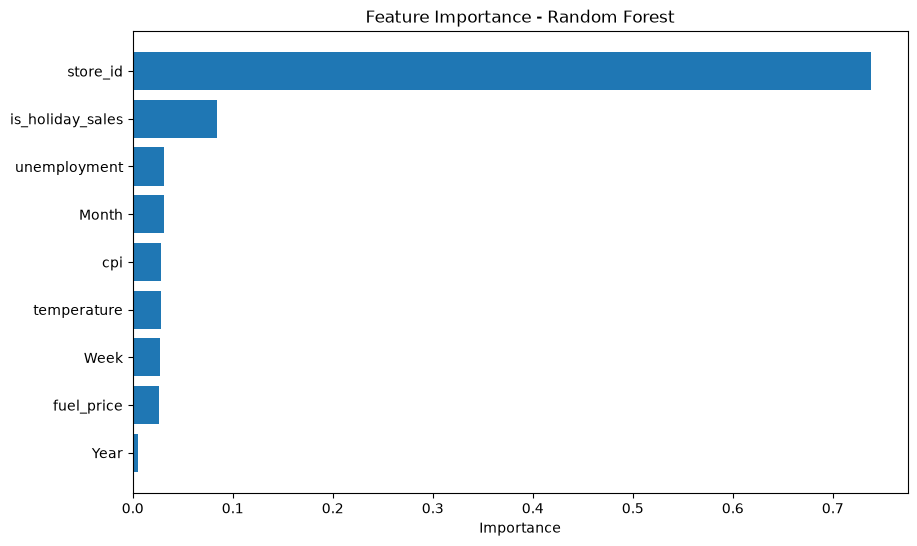

In [135]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Feature importance shows which variables contributed most to the model's sales predictions.

## Model Performance Summary

In [136]:
model_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2 Score"
    ],
    "Value": [
        rf_mae,
        rf_rmse,
        rf_r2
    ]
})

model_results

,Metric,Value
0,MAE,27477.298322
1,RMSE,38723.887438
2,R2 Score,0.409915


In [137]:
results["Error"] = (
    results["Actual"]
    - results["Predicted"]
)

In [138]:
results.head()

,Actual,Predicted,Error
0,39417.23,74644.522852,-35227.292852
1,16018.74,74644.522852,-58625.782852
2,22512.94,61989.996560,-39477.056560
3,22479.93,61989.996560,-39510.066560
4,182351.42,61989.996560,120361.423440


In [139]:
results["Absolute_Error"] = abs(results["Error"])

results.head()

,Actual,Predicted,Error,Absolute_Error
0,39417.23,74644.522852,-35227.292852,35227.292852
1,16018.74,74644.522852,-58625.782852,58625.782852
2,22512.94,61989.996560,-39477.056560,39477.056560
3,22479.93,61989.996560,-39510.066560,39510.066560
4,182351.42,61989.996560,120361.423440,120361.423440


In [140]:
import joblib

In [152]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

# Save model
Path("../models").mkdir(parents=True, exist_ok=True)
joblib.dump(rf_model, "../models/random_forest_sales_model.pkl")

# Prepare predictions dataframe aligned with the test split when possible
Path("../output").mkdir(parents=True, exist_ok=True)

if 'split_index' in globals() and 'model_df' in globals():
    ids = model_df.iloc[split_index:].reset_index(drop=True)
    id_cols = [c for c in ['store_id', 'date', 'department'] if c in ids.columns]
    pred_df = ids[id_cols].copy() if id_cols else pd.DataFrame()
    pred_df = pred_df.reset_index(drop=True)
    pred_df['Predicted'] = pd.Series(rf_predictions).reset_index(drop=True)
    if 'y_test' in globals():
        pred_df['Actual'] = y_test.reset_index(drop=True)
else:
    pred_df = pd.DataFrame({'Predicted': pd.Series(rf_predictions)})
    if 'y_test' in globals():
        pred_df['Actual'] = y_test.reset_index(drop=True)

# Add error metrics
if 'Actual' in pred_df.columns:
    pred_df['Error'] = pred_df['Actual'] - pred_df['Predicted']
    pred_df['Absolute_Error'] = pred_df['Error'].abs()
    # Avoid division by zero
    pred_df['Absolute_Pct_Error'] = np.where(
        pred_df['Actual'] == 0,
        np.nan,
        (pred_df['Absolute_Error'] / pred_df['Actual']) * 100
    )

# Format date readable
if 'date' in pred_df.columns:
    pred_df['date'] = pd.to_datetime(pred_df['date']).dt.strftime('%Y-%m-%d')

# Save enriched CSV (and also overwrite the simpler CSV for compatibility)
out_enriched = Path('../output/sales_predictions_enriched.csv')
out_simple = Path('../output/sales_predictions.csv')
pred_df.to_csv(out_enriched, index=False)
pred_df.to_csv(out_simple, index=False)

# Print quick summary to help explanation
n = len(pred_df)
print(f"Wrote {n} rows to {out_enriched} and {out_simple}")
if 'Actual' in pred_df.columns:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = mean_absolute_error(pred_df['Actual'], pred_df['Predicted'])
    rmse = np.sqrt(mean_squared_error(pred_df['Actual'], pred_df['Predicted']))
    r2 = r2_score(pred_df['Actual'], pred_df['Predicted'])
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}")
    print("Top 5 rows with largest absolute error:")
    display(pred_df.sort_values('Absolute_Error', ascending=False).head(5))
else:
    print("Actual values not available — CSV contains only predictions.")

Wrote 31200 rows to ../output/sales_predictions_enriched.csv and ../output/sales_predictions.csv
MAE: 27477.30, RMSE: 38723.89, R2: 0.410
Top 5 rows with largest absolute error:


,store_id,date,department,Predicted,Actual,Error,Absolute_Error,Absolute_Pct_Error
27584,41,2024-11-30,20,141040.917483,505958.73,364917.812517,364917.812517,72.124027
27085,24,2024-11-23,20,130007.083874,479940.11,349933.026126,349933.026126,72.911811
27451,47,2024-11-30,19,71708.843615,388915.43,317206.586385,317206.586385,81.561841
27206,47,2024-11-30,17,71708.843615,383051.53,311342.686385,311342.686385,81.279583
26678,5,2024-11-23,17,178433.830948,485963.00,307529.169052,307529.169052,63.282425


**How to explain this predictions CSV to your teacher**

- **File:** `output/sales_predictions_enriched.csv`
- **Columns:**
  - `store_id`, `date`, `department` — identifiers for each test row (if available).
  - `Predicted` — model's predicted weekly sales.
  - `Actual` — true weekly sales (if present).
  - `Error` = Actual - Predicted (positive means under-prediction).
  - `Absolute_Error` — magnitude of the error.
  - `Absolute_Pct_Error` — percent error relative to actual.
- **What to show in presentation:**
  - Overall metrics: MAE, RMSE, R² (printed by the cell).
  - Top 5 largest errors — explain possible reasons (holiday, markdowns, outliers).
  - Example good predictions vs. bad predictions (pick a few rows from the CSV).
- **Talking points:**
  - How the model was trained (chronological 80/20 split), features used, and how missing values were handled.
  - Limitations: store_id treated as numeric, special events/holidays can cause spikes the model missed.
  - Next steps: add categorical encoding, more temporal features, or try specialized time-series models.

This gives you a simple CSV to open in Excel and a short script output (MAE/RMSE/R² and top errors) to reference while explaining.

In [144]:
joblib.dump(
    model_features,
    "../models/model_features.pkl"
)

['../models/model_features.pkl']

In [145]:
from pathlib import Path

Path("../outputs/predictions").mkdir(
    parents=True,
    exist_ok=True
)

In [146]:
prediction_output = model_df.iloc[
    split_index:
][["date", "store_id"]].copy()

In [147]:
if "dept_id" in model_df.columns:
    prediction_output["dept_id"] = (
        model_df.iloc[split_index:]["dept_id"].values
    )

In [148]:
prediction_output["actual_sales"] = y_test.values
prediction_output["predicted_sales"] = rf_predictions

In [149]:
prediction_output.to_csv(
    "../outputs/predictions/sales_predictions.csv",
    index=False
)

## Machine Learning Conclusion

A Random Forest Regressor was used to forecast weekly retail sales.

The model was trained using historical store, date, holiday,
economic, and engineered sales features.

Model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Actual and predicted sales were compared visually, and feature
importance was used to understand the factors influencing the model.